In [558]:
from cycler import concat
from tensorflow.compiler.tf2xla.python.xla import concatenate
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv2D,Dense,Dropout,Input,LSTM,GRU,concatenate
import pandas as pd 
import numpy as np 


In [559]:
data=pd.read_csv("usdt-usd-max.csv")
data[:10]

,snapped_at,price,market_cap,total_volume
0,2015-02-25 00:00:00 UTC,1.210160,304476.0,5.0
1,2015-03-02 00:00:00 UTC,0.572521,144046.0,2.0
2,2015-03-06 00:00:00 UTC,1.000000,251600.0,50.0
3,2015-03-07 00:00:00 UTC,1.000000,251600.0,58196.0
4,2015-03-08 00:00:00 UTC,1.000000,251600.0,31.0
5,2015-03-09 00:00:00 UTC,1.000000,251600.0,137.0
6,2015-03-10 00:00:00 UTC,1.000000,251600.0,50006.0
7,2015-03-11 00:00:00 UTC,1.000000,251600.0,46.0
8,2015-03-12 00:00:00 UTC,1.000000,251600.0,80421.0
9,2015-03-13 00:00:00 UTC,1.000000,251600.0,75.0


In [562]:
data2=pd.read_excel("tether.xlsx")
data2

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,timeOpen,timeClose,timeHigh,timeLow,priceOpen,priceHigh,priceLow,priceClose,volume
0,1770033600000,1770119999999,1770053820000,1770057780000,0.999001,1.001027,0.997636,0.999132,1.779279e+11
1,1769947200000,1770033599999,1769985240000,1770018480000,0.998866,1.000378,0.998374,0.999110,1.164217e+11
2,1769860800000,1769947199999,1769912820000,1769928300000,0.998428,1.002031,0.996447,0.998891,1.505837e+11
3,1769774400000,1769860799999,1769830440000,1769780640000,0.998352,1.000805,0.997380,0.998488,1.418299e+11
4,1769688000000,1769774399999,1769697180000,1769763240000,0.998908,0.999463,0.997865,0.998339,1.255133e+11
...,...,...,...,...,...,...,...,...,...
2694,1535284800000,1535371199999,1535294040000,1535335141000,1.003210,1.007950,0.997750,0.999227,1.946530e+09
2695,1535198400000,1535284799999,1535256543000,1535251441000,0.998537,1.003820,0.995268,1.001000,1.958700e+09
2696,1535112000000,1535198399999,1535165041000,1535180342000,0.998429,1.008960,0.994293,1.001780,2.850500e+09
2697,1535025600000,1535111999999,1535059742000,1535076544000,1.001350,1.004250,0.993635,0.998976,2.392970e+09


In [563]:
data2.isnull().sum()

timeOpen      0
timeClose     0
timeHigh      0
timeLow       0
priceOpen     0
priceHigh     0
priceLow      0
priceClose    0
volume        0
dtype: int64

In [598]:
def normalize(df):
    return (df-df.min())/(df.max()-df.min())

In [599]:
data['return'] = data['price'].pct_change()
data['ma_5'] = data['price'].rolling(5).mean()
future = data['price'].shift(-10)
data['buy'] = (future > data['price']*1.01).astype(int)

data = data.dropna()
d1 = ['price', 'return', 'ma_5', 'buy']

In [600]:
data2['return'] = data2['priceClose'].pct_change()
data2['h1_spread'] = data2['priceHigh'] - data2['priceLow']
data2['ma_5'] = data2['priceClose'].rolling(5).mean()
data2['ma_10'] = data2['priceClose'].rolling(10).mean()

future_price = data2['priceClose'].shift(-10)
valid_idx = future_price.notna()
data2.loc[valid_idx, 'buy'] = (future_price[valid_idx] > data2.loc[valid_idx, 'priceClose']*1.01).astype(int)

data2 = data2.dropna()

d2 = ['priceClose', 'return', 'h1_spread', 'ma_5', 'ma_10', 'volume', 'buy']

C:\Users\LOQ\AppData\Local\Temp\ipykernel_26528\3564664911.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['return'] = data2['priceClose'].pct_change()
C:\Users\LOQ\AppData\Local\Temp\ipykernel_26528\3564664911.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['h1_spread'] = data2['priceHigh'] - data2['priceLow']
C:\Users\LOQ\AppData\Local\Temp\ipykernel_26528\3564664911.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [601]:
future_price.isna().sum()

np.int64(10)

In [602]:
data.columns

Index(['snapped_at', 'price', 'market_cap', 'total_volume', 'return', 'ma_5',
       'buy'],
      dtype='object')

In [569]:
data1_scaled=normalize(data[d1])
data2_scaled=normalize(data2[d2])

In [570]:
def make_sequence(df,time_step):
    seq=[]
    for i in range(time_step,len(df)):
        seq.append(df[i-time_step:i].values)
    return np.array(seq)


In [571]:
x1_seq=make_sequence(data1_scaled,time_step)
x2_seq=make_sequence(data2_scaled,time_step)
min_x=min(len(x1_seq),len(x2_seq))

y=data['buy'].iloc[time_step:].values
y=y[-min_x:]
x1_seq=x1_seq[:min_x]
x2_seq=x2_seq[:min_x]

In [572]:
n_feachers1=x1_seq.shape[2]
n_feachers2=x2_seq.shape[2]

In [589]:
model=Sequential()

model.add(LSTM(1,return_sequences=True,input_shape=(time_step,n_feachers1)))
model.add(Dropout(0.3))
model.add(LSTM(42,return_sequences=True))
model.add(Dense(1,activation='sigmoid'))

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [590]:
model2=Sequential()
model2.add(LSTM(12,return_sequences=True,input_shape=(time_step,n_feachers2)))
model2.add(Dropout(0.3))
model2.add(LSTM(32,return_sequences=True))

model2.add(Dense(1,activation='sigmoid'))

In [591]:
input1=Input(shape=(time_step,n_feachers1))
input2=Input(shape=(time_step,n_feachers2))

In [592]:
out1=LSTM(64,return_sequences=True)(input1)
out1=Dropout(0.3)(out1)
out1=LSTM(64,return_sequences=False)(out1)
out1=Dense(1,activation='sigmoid')(out1)

In [593]:
out2=LSTM(12,return_sequences=False)(input2)
out2=Dense(1,activation='sigmoid')(out2)

In [594]:
merged=concatenate([out1,out2])
f_output=Dense(1,activation='sigmoid')(merged)

In [595]:
multi=Model([input1,input2],outputs=f_output)
multi.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [596]:
model.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_170 (LSTM)                 │ (None, 30, 12)         │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_171 (LSTM)                 │ (None, 30, 42)         │         9,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 30, 1)          │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,099 (39.45 KB)

 Trainable params: 10,099 (39.45 KB)

 Non-trainable params: 0 (0.00 B)

In [597]:
history=multi.fit([x1_seq,x2_seq],y,batch_size=10,epochs=10,)

Epoch 1/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9928 - loss: 0.4441
Epoch 2/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9928 - loss: 0.2565
Epoch 3/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9928 - loss: 0.1688
Epoch 4/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9928 - loss: 0.1222
Epoch 5/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9928 - loss: 0.0953
Epoch 6/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9928 - loss: 0.0786
Epoch 7/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9928 - loss: 0.0678
Epoch 8/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9928 - loss: 0.0605
Epoch 9/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9928 - loss: 0.0554
Epoch 10/10
265/265 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9928 - loss: 0.0518


In [584]:
multi.save("TTR.keras")

KeyError: 'val_accuracy'

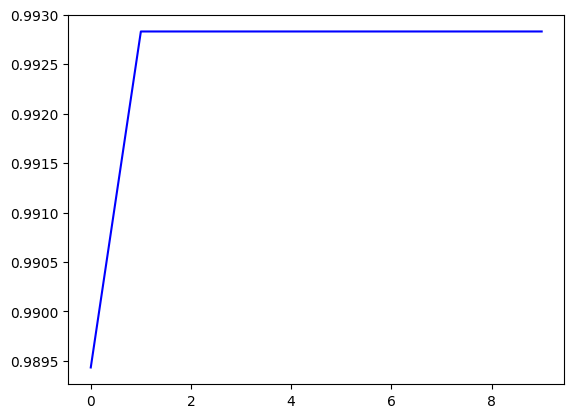

In [585]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="accuracy",color ="blue")
plt.plot(history.history["val_accuracy"],label="val_a",color="green")

In [586]:
from tensorflow.keras.models import load_model
multi=load_model('TTR.keras')

In [587]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

time_step = 30  # طول سکوانس

def predict_signal(new_data1, new_data2, model, time_step=30):
    """
    پیش‌بینی سیگنال خرید یا فروش با مدل چندورودی.
    اگر داده کمتر از time_step باشد، خودش داده را pad می‌کند.
    """
    # نرمال سازی
    def normalize(df):
        return (df - df.min()) / (df.max() - df.min() + 1e-8)  # +1e-8 برای جلوگیری از تقسیم بر صفر

    # pad کردن داده‌ها اگر کمتر از time_step باشند
    def pad_data(df, time_step):
        if len(df) < time_step:
            pad_len = time_step - len(df)
            # تکرار اولین ردیف برای پر کردن
            pad_rows = pd.DataFrame(np.repeat(df.iloc[[0]].values, pad_len, axis=0), columns=df.columns)
            df = pd.concat([pad_rows, df], ignore_index=True)
        return df

    new_data1 = pad_data(new_data1, time_step)
    new_data2 = pad_data(new_data2, time_step)

    # نرمال سازی
    new_data1_scaled = normalize(new_data1)
    new_data2_scaled = normalize(new_data2)

    # ساخت سکوانس
    def make_sequence(df, time_step):
        seq = []
        for i in range(time_step, len(df)+1):
            seq.append(df[i-time_step:i].values)
        return np.array(seq)

    x1_seq = make_sequence(new_data1_scaled, time_step)
    x2_seq = make_sequence(new_data2_scaled, time_step)

    # کوتاه کردن به حداقل طول دو ورودی
    min_len = min(len(x1_seq), len(x2_seq))
    x1_seq = x1_seq[:min_len]
    x2_seq = x2_seq[:min_len]

    # پیش‌بینی
    pred = model.predict([x1_seq, x2_seq], verbose=0)
    last_pred = pred[-1][0]

    return "Buy" if last_pred > 0.5 else "Sell"


In [588]:
# داده ورودی اول کم‌تر از 30 ردیف
new_data1 = pd.DataFrame({
    'price': np.linspace(1.00, 1.05, time_step),          # قیمت صعودی
    'return': np.linspace(0.0005, 0.001, time_step),      # تغییر درصد مثبت
    'ma_5': np.linspace(1.00, 1.045, time_step),          # میانگین 5 روزه صعودی
    'buy': np.zeros(time_step)                             # ستون buy صفر
})

# --- داده ورودی دوم (data2) صعودی ---
new_data2 = pd.DataFrame({
    'priceClose': np.linspace(1.00, 1.06, time_step),
    'return': np.linspace(0.0007, 0.0012, time_step),
    'h1_spread': np.random.uniform(0.0001, 0.0003, time_step),  # کمی نویز
    'ma_5': np.linspace(1.00, 1.05, time_step),
    'ma_10': np.linspace(1.00, 1.055, time_step),
    'volume': np.random.randint(2000, 5000, time_step),
    'buy': np.zeros(time_step)
})

# لود مدل
multi = load_model('TTR.keras')

# پیش‌بینی سیگنال
signal = predict_signal(new_data1, new_data2, multi)
print("Signal:", signal)


Signal: Sell
